**Preparación Inicial: Configuración del Entorno y Datos**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_validate
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# 1. Carga y segmentación segura de los datos
df = pd.read_csv('data/house_pricing.csv')
df_labeled = df[df['Split'] == 'labeled'].copy()

X_train = df_labeled.drop(['SalePrice', 'Split', 'Id'], axis=1)
y_train = df_labeled['SalePrice']

# 2. Reutilización del preprocesador robusto contra nulos
cat_features = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_features),
        ('cat', Pipeline([('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))]), cat_features)
    ]
)

# Definimos el esquema de validación cruzada fijo para todos los ejercicios (p.ej., 5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

**Ejercicio 1: Árbol de Decisión (Decision Tree)**

1.A. Estudio de la Profundidad Máxima (max_depth)

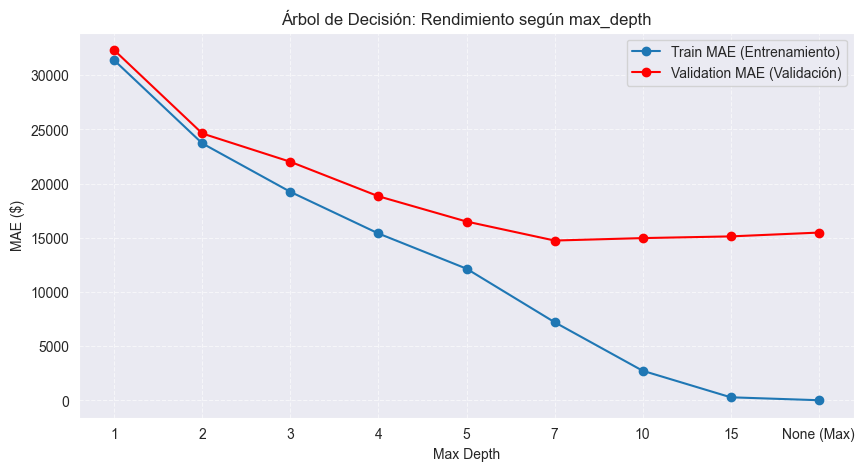

In [2]:
depths = [1, 2, 3, 4, 5, 7, 10, 15, None]
train_maes = []
val_maes = []

for d in depths:
    # Definimos la Pipeline con el estimador y su profundidad correspondiente
    dt_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('dt', DecisionTreeRegressor(max_depth=d, random_state=42))
    ])

    # Validación cruzada extrayendo el score de train y val
    cv_res = cross_validate(dt_pipe, X_train, y_train, cv=kf,
                            scoring='neg_mean_absolute_error', return_train_score=True, n_jobs=-1)

    train_maes.append(-cv_res['train_score'].mean())
    val_maes.append(-cv_res['test_score'].mean())

# Convertir None a un string o número para graficar adecuadamente
depth_labels = [str(d) if d is not None else 'None (Max)' for d in depths]

# Graficar resultados
plt.figure(figsize=(10, 5))
plt.plot(depth_labels, train_maes, marker='o', label='Train MAE (Entrenamiento)')
plt.plot(depth_labels, val_maes, marker='o', label='Validation MAE (Validación)', color='red')
plt.title('Árbol de Decisión: Rendimiento según max_depth')
plt.xlabel('Max Depth')
plt.ylabel('MAE ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

1.B. Estudio de min_samples_split y min_samples_leaf

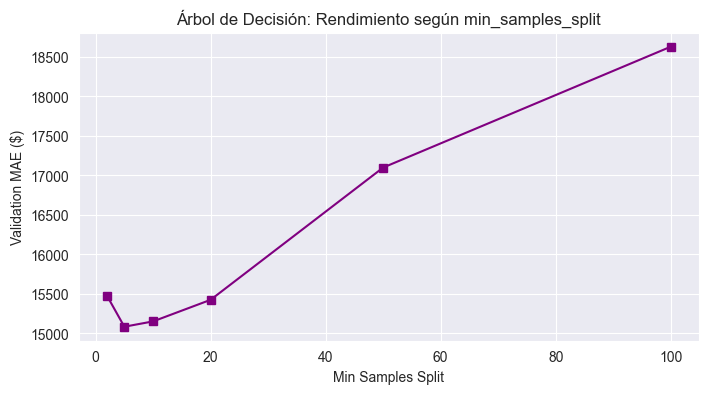

In [3]:
splits = [2, 5, 10, 20, 50, 100]
val_maes_split = []

for s in splits:
    dt_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('dt', DecisionTreeRegressor(min_samples_split=s, random_state=42))
    ])
    cv_res = cross_validate(dt_pipe, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
    val_maes_split.append(-cv_res['test_score'].mean())

plt.figure(figsize=(8, 4))
plt.plot(splits, val_maes_split, marker='s', color='purple')
plt.title('Árbol de Decisión: Rendimiento según min_samples_split')
plt.xlabel('Min Samples Split')
plt.ylabel('Validation MAE ($)')
plt.grid(True)
plt.show()

1.C. Entrenar un árbol de profundidad baja (3 o 4) y representarlo gráficamente

C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\.venv_py312\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['Electtrical']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


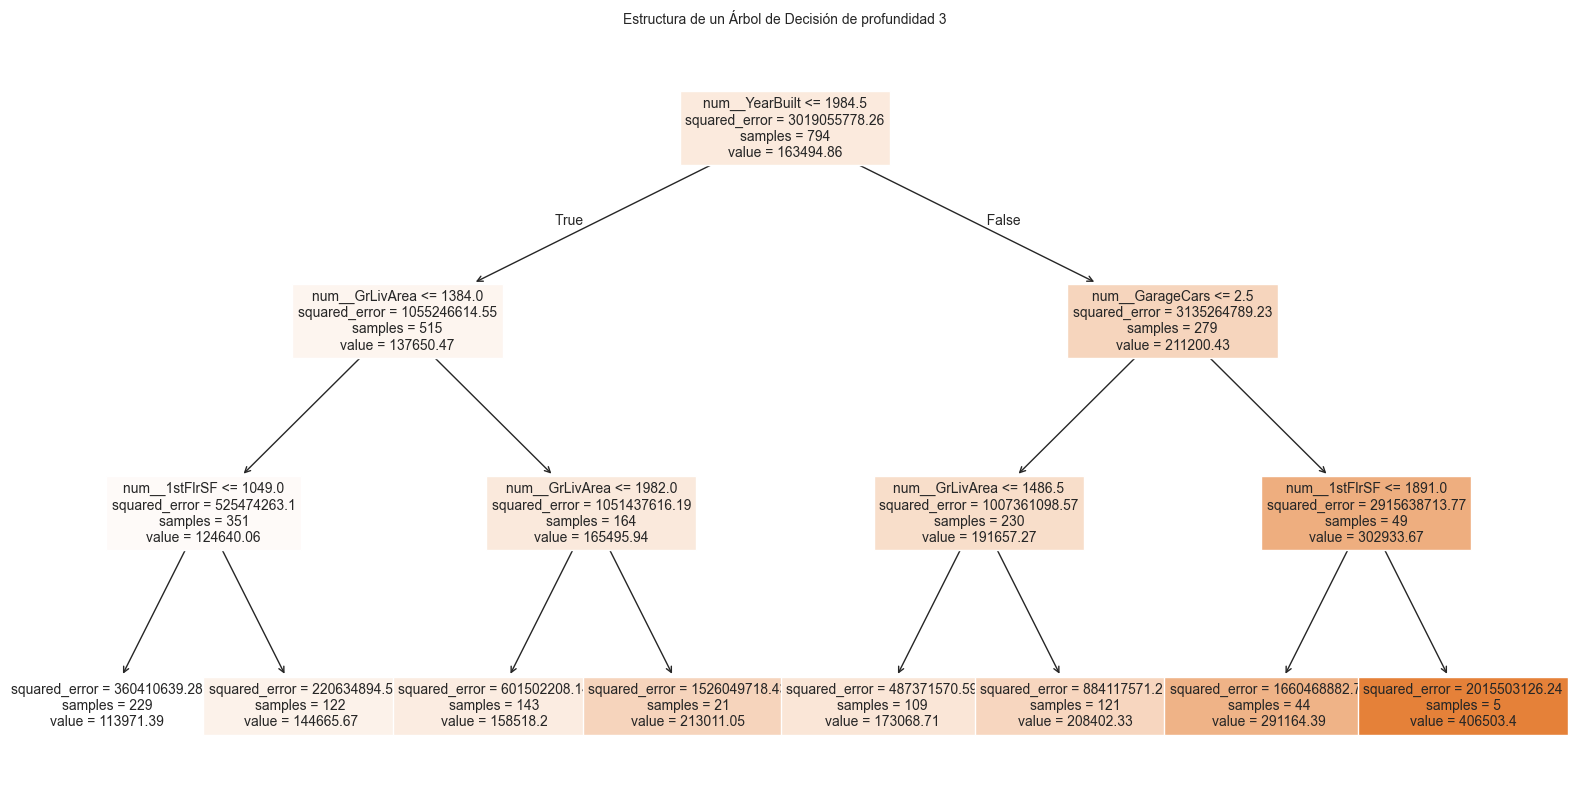

In [10]:
# Entrenamos el árbol de forma directa
dt_low = DecisionTreeRegressor(max_depth=3, random_state=42)

# Ajustamos primero el preprocesador y luego el árbol para extraer nombres de columnas reales
X_transformed = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()

dt_low.fit(X_transformed, y_train)

# Representación gráfica
plt.figure(figsize=(20, 10))
plot_tree(dt_low, feature_names=feature_names, filled=True, fontsize=10, precision=2)
plt.title("Estructura de un Árbol de Decisión de profundidad 3", fontsize=10)
plt.show()

**Ejercicio 2: Random Forest (RF)**

2.A. Estudio del Número de Estimadores (n_estimators)

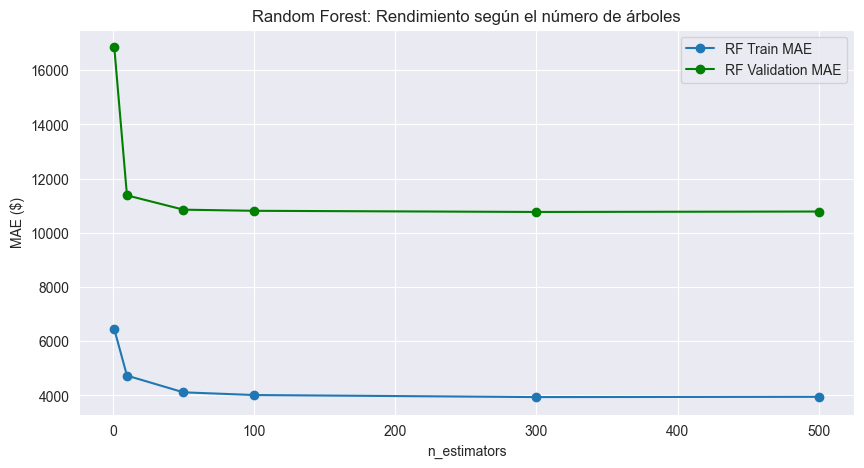

In [5]:
estimators = [1, 10, 50, 100, 300, 500] # Evaluamos hasta 500 (suficiente para ver la convergencia)
rf_train_maes = []
rf_val_maes = []

for n in estimators:
    rf_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('rf', RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1))
    ])
    cv_res = cross_validate(rf_pipe, X_train, y_train, cv=kf,
                            scoring='neg_mean_absolute_error', return_train_score=True, n_jobs=-1)
    rf_train_maes.append(-cv_res['train_score'].mean())
    rf_val_maes.append(-cv_res['test_score'].mean())

# Gráfica de evolución
plt.figure(figsize=(10, 5))
plt.plot(estimators, rf_train_maes, marker='o', label='RF Train MAE')
plt.plot(estimators, rf_val_maes, marker='o', color='green', label='RF Validation MAE')
plt.title('Random Forest: Rendimiento según el número de árboles')
plt.xlabel('n_estimators')
plt.ylabel('MAE ($)')
plt.legend()
plt.grid(True)
plt.show()

2.B. Analizar la importancia de las características (Feature Importance)

C:\Users\fundacion\AppData\Local\Temp\ipykernel_18620\2288199969.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Característica', data=importances_df.head(10), palette='viridis')


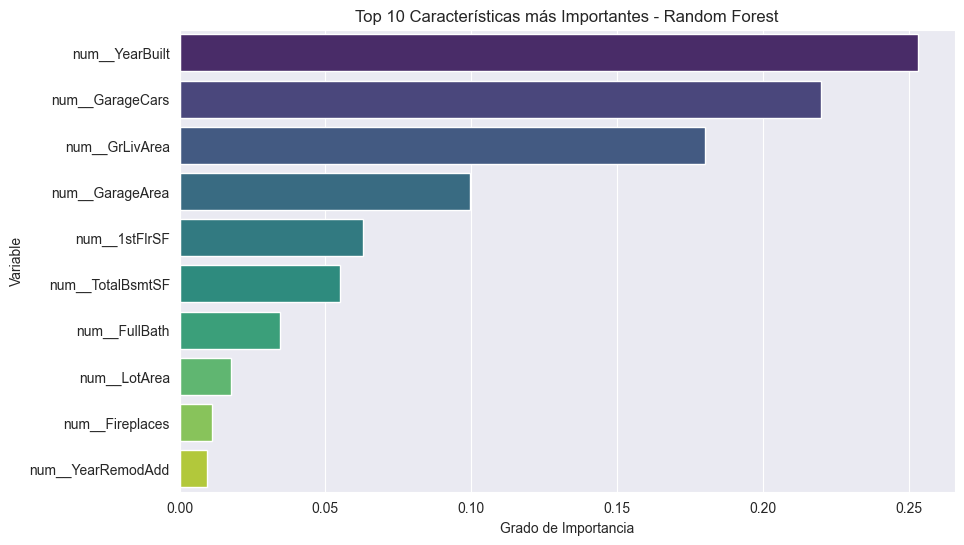

In [6]:
rf_final = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Entrenamos con los datos preprocesados
rf_final.fit(X_transformed, y_train)

# Crear DataFrame con las importancias
importances_df = pd.DataFrame({
    'Característica': feature_names,
    'Importancia': rf_final.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Mostrar las 10 características más determinantes
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Característica', data=importances_df.head(10), palette='viridis')
plt.title('Top 10 Características más Importantes - Random Forest')
plt.xlabel('Grado de Importancia')
plt.ylabel('Variable')
plt.show()

Usando max_features

=== EVALUANDO MAX_FEATURES EN RANDOM FOREST ===
Configuración sqrt -> Validation MAE: 11129.3 $
Configuración log2 -> Validation MAE: 11131.9 $
Configuración 0.2 -> Validation MAE: 10775.6 $
Configuración 0.5 -> Validation MAE: 10524.2 $
Configuración 0.8 -> Validation MAE: 10785.5 $
Configuración None (100% features) -> Validation MAE: 10808.0 $


C:\Users\fundacion\AppData\Local\Temp\ipykernel_18620\3784898017.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_labels, y=rf_val_maes_features, palette='Blues_r')


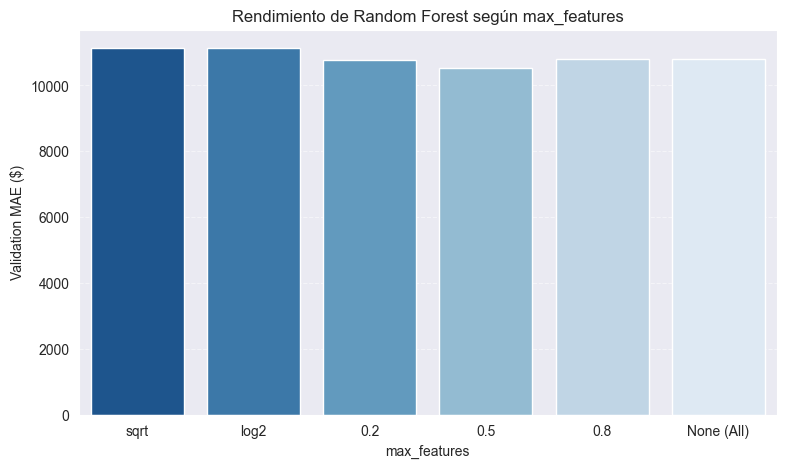

In [9]:
# Definimos las opciones de max_features que queremos comparar
max_features_options = ['sqrt', 'log2', 0.2, 0.5, 0.8, None]
rf_val_maes_features = []

print("=== EVALUANDO MAX_FEATURES EN RANDOM FOREST ===")

for feat in max_features_options:
    # Creamos la Pipeline para cada opción
    rf_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('rf', RandomForestRegressor(n_estimators=100, max_features=feat, random_state=42, n_jobs=-1))
    ])

    # Ejecutamos la validación cruzada (usando el KFold 'kf' que definimos antes)
    cv_res = cross_validate(rf_pipe, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)

    # Guardamos el MAE promedio de validación
    mean_mae = -cv_res['test_score'].mean()
    rf_val_maes_features.append(mean_mae)

    label = str(feat) if feat is not None else 'None (100% features)'
    print(f"Configuración {label} -> Validation MAE: {mean_mae:.1f} $")

# Graficar los resultados para comparar
plt.figure(figsize=(9, 5))
feature_labels = [str(f) if f is not None else 'None (All)' for f in max_features_options]
sns.barplot(x=feature_labels, y=rf_val_maes_features, palette='Blues_r')
plt.title('Rendimiento de Random Forest según max_features')
plt.xlabel('max_features')
plt.ylabel('Validation MAE ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Ejercicio 3: Gradient Boosted Decision Trees (GBDT)**

3.A. Estudio de la Tasa de Aprendizaje (learning_rate)

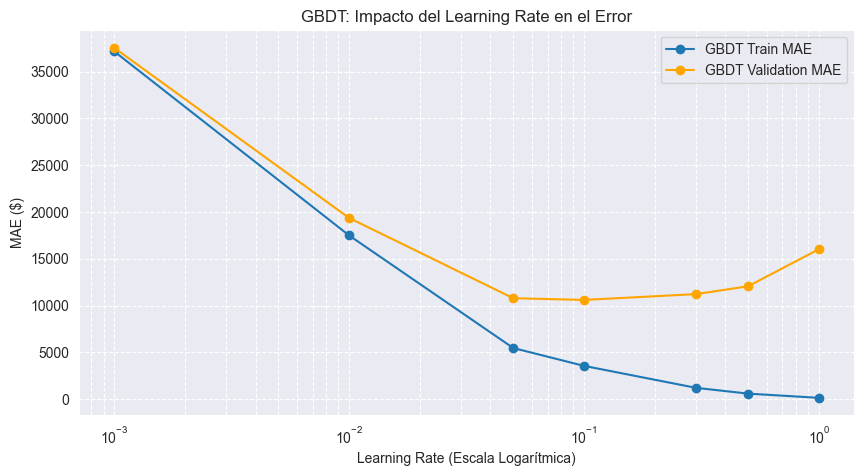

In [8]:
rates = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0]
gbdt_train_maes = []
gbdt_val_maes = []

for lr_rate in rates:
    gbdt_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('gbdt', HistGradientBoostingRegressor(learning_rate=lr_rate, max_iter=100, random_state=42))
    ])
    cv_res = cross_validate(gbdt_pipe, X_train, y_train, cv=kf,
                            scoring='neg_mean_absolute_error', return_train_score=True, n_jobs=-1)
    gbdt_train_maes.append(-cv_res['train_score'].mean())
    gbdt_val_maes.append(-cv_res['test_score'].mean())

# Gráfica comparativa
plt.figure(figsize=(10, 5))
plt.plot(rates, gbdt_train_maes, marker='o', label='GBDT Train MAE')
plt.plot(rates, gbdt_val_maes, marker='o', color='orange', label='GBDT Validation MAE')
plt.xscale('log') # Escala logarítmica para ver mejor los valores pequeños
plt.title('GBDT: Impacto del Learning Rate en el Error')
plt.xlabel('Learning Rate (Escala Logarítmica)')
plt.ylabel('MAE ($)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()